### 기본 설정

In [2]:
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc
import os


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


# 로그
import logging

def init_logger() -> logging.Logger:
    logging.basicConfig(
        format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        encoding="utf-8",
    )
    return logging.getLogger("")

logger = init_logger()

Matplotlib is building the font cache; this may take a moment.


## 데이터 확인

In [3]:
import glob
from pycocotools.coco import COCO

BASE_JSON = COCO("./data/COCO_Football Pixel.json")

IMAGE_NAME_LIST = sorted(os.listdir("./data/images/"))
IMAGE_PATH_LIST = sorted(glob.glob(f"./data/images/*"))

loading annotations into memory...
Done (t=0.32s)
creating index...
index created!


In [4]:
IMAGE_PATH_LIST

['./data/images/Frame 1  (1).jpg',
 './data/images/Frame 1  (1).jpg___fuse.png',
 './data/images/Frame 1  (1).jpg___save.png',
 './data/images/Frame 1  (10).jpg',
 './data/images/Frame 1  (10).jpg___fuse.png',
 './data/images/Frame 1  (10).jpg___save.png',
 './data/images/Frame 1  (100).jpg',
 './data/images/Frame 1  (100).jpg___fuse.png',
 './data/images/Frame 1  (100).jpg___save.png',
 './data/images/Frame 1  (11).jpg',
 './data/images/Frame 1  (11).jpg___fuse.png',
 './data/images/Frame 1  (11).jpg___save.png',
 './data/images/Frame 1  (12).jpg',
 './data/images/Frame 1  (12).jpg___fuse.png',
 './data/images/Frame 1  (12).jpg___save.png',
 './data/images/Frame 1  (13).jpg',
 './data/images/Frame 1  (13).jpg___fuse.png',
 './data/images/Frame 1  (13).jpg___save.png',
 './data/images/Frame 1  (14).jpg',
 './data/images/Frame 1  (14).jpg___fuse.png',
 './data/images/Frame 1  (14).jpg___save.png',
 './data/images/Frame 1  (15).jpg',
 './data/images/Frame 1  (15).jpg___fuse.png',
 './dat

원본에 '___fuse'·'___save'를 추가한 형식으로, 세 파일당 한 묶음의 데이터로 구성되어 있다.

In [5]:
print("[누락 파일 점검]")

tmp_list, err_list = [], []

for name in IMAGE_NAME_LIST:
    tmp_list.append(int(name.split("(")[-1].split(")")[0]))

for i in range(100):
    tmp_count = tmp_list.count(i+1)
    if tmp_count != 3:
        err_list.append(i)

print(f"누락 파일: {err_list if len(err_list) != 0 else '0개'}")

[누락 파일 점검]
누락 파일: 0개


In [6]:
NORM_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith(".jpg")]
FUSE_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith("fuse.png")]
SAVE_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith("save.png")]

NORM_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith(".jpg")]
FUSE_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith("fuse.png")]
SAVE_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith("save.png")]

### 이미지 데이터

In [7]:
print(f"[사이즈 정보]")

import random
import torchvision

rand_idx = random.randint(1, len(NORM_PATH_LIST))

sample_norm_image = torchvision.io.read_image(NORM_PATH_LIST[rand_idx])
sample_fuse_image = torchvision.io.read_image(FUSE_PATH_LIST[rand_idx])
sample_save_image = torchvision.io.read_image(SAVE_PATH_LIST[rand_idx])

print(f"· 원본 이미지: {sample_norm_image.shape}")
print(f"· fuse 이미지: {sample_fuse_image.shape}")
print(f"· save 이미지: {sample_save_image.shape}")

H, W = 1080, 1920

[사이즈 정보]
· 원본 이미지: torch.Size([3, 1080, 1920])
· fuse 이미지: torch.Size([4, 1080, 1920])
· save 이미지: torch.Size([4, 1080, 1920])


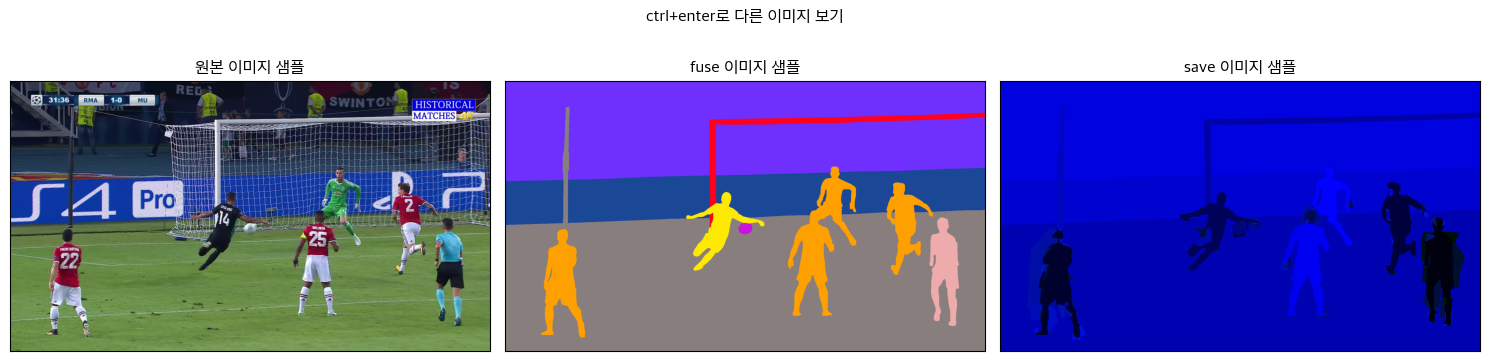

In [8]:
# 샘플 이미지 출력

# 축 숫자 표기 제거 함수 생성
def remove_ticks(columns=2):
    for num in range(columns):
        axes[num].set_xticks([])
        axes[num].set_yticks([])


rand_idx = random.randint(1, len(NORM_PATH_LIST))

sample_norm_image = torchvision.io.read_image(NORM_PATH_LIST[rand_idx]).permute(1, 2, 0)
sample_fuse_image = torchvision.io.read_image(FUSE_PATH_LIST[rand_idx])[:3, :, :].permute(1, 2, 0)
sample_save_image = torchvision.io.read_image(SAVE_PATH_LIST[rand_idx])[:3, :, :].permute(1, 2, 0)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(sample_norm_image)
axes[1].imshow(sample_fuse_image)
axes[2].imshow(sample_save_image)

fig.suptitle("ctrl+enter로 다른 이미지 보기")
axes[0].set_title("원본 이미지 샘플")
axes[1].set_title("fuse 이미지 샘플")
axes[2].set_title("save 이미지 샘플")

remove_ticks(3)
plt.tight_layout()
plt.show()

save 이미지는 같은 클래스도 다르게 구분 짓는다는 점과 경계가 불분명하다는 점에서

학습에 유리한 작용을 주지 않을 가능성이 높다고 판단된다.

학습에는 fuse 이미지를 이용한다.

### json 데이터

In [9]:
# json 샘플 데이터 확인
img_id = random.randint(1, len(BASE_JSON.getImgIds()))
ann_ids = BASE_JSON.getAnnIds(img_id)

print(f"[json 샘플 데이터 (img_id: {img_id})]")

for ann_id in ann_ids:
    anns = BASE_JSON.loadAnns(ann_id)
    for ann in anns:
        for key, value in ann.items():
            print(f"· {key}:  {value}")
        print("")

[json 샘플 데이터 (img_id: 34)]
· id:  298
· image_id:  34
· segmentation:  [[119, 268, 118, 269, 117, 269, 116, 269, 115, 270, 114, 270, 113, 271, 112, 271, 111, 272, 110, 273, 109, 274, 108, 275, 107, 276, 106, 276, 105, 277, 104, 278, 103, 279, 102, 280, 101, 280, 100, 281, 99, 282, 98, 283, 98, 284, 98, 285, 97, 286, 97, 287, 97, 288, 96, 289, 96, 290, 96, 291, 96, 292, 95, 293, 95, 294, 95, 295, 94, 296, 94, 297, 94, 298, 93, 299, 93, 300, 93, 301, 93, 302, 93, 303, 93, 304, 93, 305, 93, 306, 92, 307, 92, 308, 92, 309, 92, 310, 91, 311, 91, 312, 91, 313, 92, 314, 92, 315, 92, 316, 93, 317, 94, 318, 95, 319, 96, 320, 97, 321, 98, 322, 99, 323, 100, 324, 101, 325, 102, 326, 102, 327, 102, 328, 102, 329, 102, 330, 102, 331, 102, 332, 102, 333, 102, 334, 102, 335, 102, 336, 102, 337, 102, 338, 102, 339, 102, 340, 102, 341, 102, 342, 102, 343, 102, 344, 101, 345, 100, 345, 99, 345, 98, 346, 97, 346, 96, 347, 95, 348, 94, 348, 93, 349, 92, 349, 91, 350, 90, 351, 89, 351, 88, 352, 87, 352, 86

In [10]:
# 모든 카테고리
categories = BASE_JSON.loadCats(BASE_JSON.getCatIds())
print(f"[총 카테고리 ({len(categories)}개)]")

category_id_set = set([category["id"] for category in categories])

for category in categories:
    print(f"· {category['name']} (id: {category['id']})")
    

# 실제로 쓰인 카테고리
used_category_id_set = set()

img_ids = BASE_JSON.getImgIds()

for img_id in img_ids:
    ann_ids = BASE_JSON.getAnnIds(img_id)
    for ann_id in ann_ids:
        anns = BASE_JSON.loadAnns(ann_id)
        for ann in anns:
            used_category_id_set.add(ann["category_id"])

print(f"\n[실제 쓰인 카테고리 ({len(used_category_id_set)}개)]")
print(f"· {used_category_id_set}")


# 쓰이지 않은 카테고리
residue_id_set = category_id_set - used_category_id_set

print(f"\n[쓰이지 않은 카테고리 ({len(residue_id_set)}개)]")
for id in residue_id_set:
    for category in categories:
        for key, value in category.items():
            if id == value:
                print(f"· {category['name']} (id: {id})")

[총 카테고리 (11개)]
· Goal Bar (id: 1393250)
· Referee (id: 1392807)
· Advertisements (id: 1392806)
· Ground (id: 1392805)
· Ball (id: 1392804)
· Coaches & Officials (id: 1392803)
· Audience (id: 1392802)
· Goalkeeper B (id: 1392801)
· Goalkeeper A (id: 1392800)
· Team B (id: 1392799)
· Team A (id: 1392794)

[실제 쓰인 카테고리 (10개)]
· {1392800, 1392801, 1392802, 1393250, 1392804, 1392805, 1392806, 1392807, 1392794, 1392799}

[쓰이지 않은 카테고리 (1개)]
· Coaches & Officials (id: 1392803)


json 데이터에 11개의 카테고리가 존재하지만, 실제로 사용된 카테고리는 10개이다.

Coaches & Officials 카테고리는 사용되지 않았으므로, 학습에서 제외한다.

In [11]:
print("[bbox 형식 확인]")

img_id = random.randint(1, len(BASE_JSON.getImgIds()))
ann_id = BASE_JSON.getAnnIds(img_id)[0]
ann = BASE_JSON.loadAnns(ann_id)[0]

bbox = [int(i) for i in ann["bbox"]]

seg = ann["segmentation"][0]
x_seg = [i for i in seg if seg.index(i) % 2 == 0]
y_seg = [i for i in seg if seg.index(i) % 2 != 0]

xyxy = [min(x_seg), min(y_seg), max(x_seg), max(y_seg)]

print(f"· xyxy: {xyxy}")
print(f"· bbox: {bbox}")

[bbox 형식 확인]
· xyxy: [368, 697, 696, 879]
· bbox: [368, 697, 370, 183]


json 데이터의 bbox는 x, y, w, h 형식임을 알 수 있다.

In [12]:
print("[background 클래스 필요성 확인]")

import pandas as pd
import numpy as np
from PIL import Image, ImageDraw

no_category_df = pd.DataFrame(columns=["img_id", "클래스 없는 픽셀 수", "전체 대비 비율"])

for img_id in BASE_JSON.getImgIds():

    ann_ids = BASE_JSON.getAnnIds(img_id)
    anns = BASE_JSON.loadAnns(ann_ids)

    frame = np.ones((H, W), dtype=np.uint8)
    category_frame = np.zeros((H, W), dtype=np.uint8)

    for ann in anns:
        for seg in ann["segmentation"]:
            x_segs = [int(seg[i]) for i in range(0, len(seg), 2)]
            y_segs = [int(seg[i+1]) for i in range(0, len(seg), 2)]
            
            tmp_mask = Image.new("L", (W, H), 0)
            draw = ImageDraw.Draw(tmp_mask)
            polygon = list(zip(x_segs, y_segs))
            draw.polygon(polygon, outline=1, fill=1)
            
            tmp_array = np.array(tmp_mask)
            ys, xs = np.where(tmp_array > 0)
            
            category_frame[ys, xs] = 1

    no_category_area = frame - category_frame

    no_category_df.loc[len(no_category_df)] = [int(img_id), int(no_category_area.sum()), f"{no_category_area.sum() / frame.sum() * 100:.2f}%"]

no_category_df = no_category_df.set_index("img_id")
no_category_df.sort_values("클래스 없는 픽셀 수", ascending=False).head(10)

[background 클래스 필요성 확인]


,클래스 없는 픽셀 수,전체 대비 비율
img_id,,
47,2160,0.10%
4,652,0.03%
89,171,0.01%
64,123,0.01%
32,109,0.01%
10,101,0.00%
45,88,0.00%
19,88,0.00%
24,44,0.00%


background라는 클래스를 하나 둘 필요성은 없는 것으로 판단된다.

In [13]:
print("[복수 클래스 픽셀 분석]")

overlap_df = pd.DataFrame(columns=["img_id", "복수 클래스 픽셀 수", "전체 대비 비율", "복수 클래스 개수", "겹친 클래스들"])

for img_id in BASE_JSON.getImgIds():
    ann_ids = BASE_JSON.getAnnIds(img_id)
    anns = BASE_JSON.loadAnns(ann_ids)

    overlap_count = np.zeros((H, W), dtype=np.uint8)
    pixel_classes = {}
    
    for ann in anns:
        cat_id = ann["category_id"]
        cat_name = BASE_JSON.loadCats(cat_id)[0]["name"]
        
        for seg in ann["segmentation"]:
            x_segs = [int(seg[i]) for i in range(0, len(seg), 2)]
            y_segs = [int(seg[i+1]) for i in range(0, len(seg), 2)]
            
            tmp_mask = Image.new("L", (W, H), 0)
            draw = ImageDraw.Draw(tmp_mask)
            polygon = list(zip(x_segs, y_segs))
            draw.polygon(polygon, outline=1, fill=1)
            
            tmp_array = np.array(tmp_mask)
            ys, xs = np.where(tmp_array > 0)
            
            overlap_count[ys, xs] += 1
            
            for y, x in zip(ys, xs):
                coord = (y, x)
                if coord not in pixel_classes:
                    pixel_classes[coord] = []
                if cat_name not in pixel_classes[coord]:
                    pixel_classes[coord].append(cat_name)

    overlapping_pixels = np.sum(overlap_count > 1)
    
    overlap_class_combinations = set()
    for coord, classes in pixel_classes.items():
        if len(classes) > 1:
            combo = tuple(sorted(classes))
            overlap_class_combinations.add(combo)
    
    overlap_class_list = [" + ".join(combo) for combo in overlap_class_combinations]
    
    total_pixels = H * W
    overlap_ratio = overlapping_pixels / total_pixels * 100
    max_overlap = overlap_count.max()

    overlap_df.loc[len(overlap_df)] = [
        int(img_id),
        int(overlapping_pixels),
        f"{overlap_ratio:.2f}%",
        int(max_overlap),
        overlap_class_list
    ]

overlap_df = overlap_df.set_index("img_id")

overlap_ratios = [float(x.strip("%")) for x in overlap_df["전체 대비 비율"]]
print(f"· 전체 대비 비율 평균: {np.mean(overlap_ratios):.2f}%")
print(f"· 복수 클래스 최대 개수 (전체): {overlap_df['복수 클래스 개수'].max()}개")


# 모든 이미지에서 겹친 클래스 조합 통계
all_combinations = []
for combos in overlap_df["겹친 클래스들"]:
    all_combinations.extend(combos)

from collections import Counter
combo_counts = Counter(all_combinations)

print("\n[가장 많이 겹치는 클래스 조합]")
for combo, count in combo_counts.most_common(10):
    print(f"· {combo}: {count}개 이미지")


# 결과 출력
result = overlap_df.sort_values("복수 클래스 픽셀 수", ascending=False).head(10)
result

[복수 클래스 픽셀 분석]
· 전체 대비 비율 평균: 1.58%
· 복수 클래스 최대 개수 (전체): 3개

[가장 많이 겹치는 클래스 조합]
· Ground + Team B: 48개 이미지
· Ground + Team A: 41개 이미지
· Ball + Ground: 38개 이미지
· Audience + Team B: 24개 이미지
· Advertisements + Team A: 24개 이미지
· Ground + Referee: 17개 이미지
· Advertisements + Team B: 15개 이미지
· Team A + Team B: 12개 이미지
· Audience + Team A: 12개 이미지
· Advertisements + Goalkeeper A: 10개 이미지


,복수 클래스 픽셀 수,전체 대비 비율,복수 클래스 개수,겹친 클래스들
img_id,,,,
46,173544,8.37%,2,"[Ball + Ground, Ground + Team B, Ground + Team A]"
58,150606,7.26%,2,"[Ball + Ground, Ground + Team B, Ground + Team A]"
36,121892,5.88%,2,"[Ball + Ground, Ground + Team B, Ground + Team..."
22,117211,5.65%,2,"[Ball + Ground, Ground + Team B, Ground + Team..."
83,115873,5.59%,2,"[Ball + Ground, Ground + Team B, Ground + Team..."
55,110822,5.34%,2,"[Ball + Ground, Ground + Team B, Ground + Team..."
100,108910,5.25%,2,"[Ball + Ground, Ground + Team B, Ground + Team..."
94,102459,4.94%,2,"[Ball + Ground, Ground + Team B, Ground + Team..."
99,92882,4.48%,2,"[Ball + Ground, Ground + Team B, Ground + Team..."


겹치는 영역이 큰 영향력을 끼치지는 않을 것으로 보이나, 

시각화를 통한 성능 평가에서 차질이 없도록 특정 클래스에 우선순위를 부여할 필요가 있다.

자명하게 Audience - Advertisements - Ground - Goal Bar의 순서로 가장 뒤쪽을 차지할 것이다.

In [14]:
# 복수 클래스 처리: 우선순위 설정 (낮은 숫자 = 먼저 그려짐 = 밑에 깔림)
PRIORITY_ORDER = {
    "Audience": 1,
    "Advertisements": 2,
    "Ground": 3,
    "Goal Bar": 4,
    "Goalkeeper A": 5,
    "Goalkeeper B": 5,
    "Team A": 5,
    "Team B": 5,
    "Referee": 5,
    "Ball": 5
    }

# 미사용 카테고리
EXCLUDED_CATEGORIES = ["Coaches & Officials"]

## 실험 설계

1. 학습 데이터

    - json 데이터를 이용한 학습

    - fuse 이미지를 이용한 학습

In [15]:
# 하이퍼파라미터
EPOCHS = 10
BATCH_SIZE = 4
IMAGE_SIZE = 256
LEARNING_RATE = 1e-4

# Train/Val Split
TRAIN_SIZE = 80
VAL_SIZE = 20

# fuse RGB 매핑 (JSON 사용하지 않고 직접 정의)
# 전체 분석에서 확인된 11개 RGB 값
FUSE_RGB_TO_CLASS = {
    (0, 0, 0): 0,           # Background/Unknown
    (27, 71, 151): 1,
    (111, 48, 253): 2,
    (137, 126, 126): 3,
    (201, 19, 223): 4,
    (238, 171, 171): 5,
    (254, 233, 3): 6,
    (255, 0, 29): 7,
    (255, 159, 0): 8,
    (255, 160, 1): 9,
    (255, 235, 0): 10,
}

NUM_CLASSES_JSON = 10  # JSON (미사용 카테고리 제외)
NUM_CLASSES_FUSE = 11  # fuse (11개 고정 RGB)

print(f"\n[클래스 개수]")
print(f"JSON: {NUM_CLASSES_JSON}개")
print(f"fuse: {NUM_CLASSES_FUSE}개")



[클래스 개수]
JSON: 10개
fuse: 11개


In [16]:
def create_prioritized_mask(img_id, coco_json, priority_order, excluded_categories, height=1080, width=1920):
    """
    우선순위를 적용하여 마스크 생성
    낮은 숫자 = 먼저 그려짐 = 밑에 깔림
    """
    ann_ids = coco_json.getAnnIds(imgIds=img_id)
    anns = coco_json.loadAnns(ann_ids)
    
    # 미사용 카테고리 필터링
    filtered_anns = []
    for ann in anns:
        cat_id = ann["category_id"]
        cat_name = coco_json.loadCats(cat_id)[0]["name"]
        if cat_name not in excluded_categories:
            filtered_anns.append(ann)
    
    # 우선순위로 정렬
    def get_priority(ann):
        cat_id = ann["category_id"]
        cat_name = coco_json.loadCats(cat_id)[0]["name"]
        return priority_order.get(cat_name, 999)
    
    sorted_anns = sorted(filtered_anns, key=get_priority)
    
    # 마스크 생성
    mask = np.zeros((height, width), dtype=np.uint8)
    
    for ann in sorted_anns:
        cat_id = ann["category_id"]
        
        # 카테고리 ID를 인덱스로 변환
        all_used_cats = sorted([c for c in coco_json.getCatIds() 
                               if coco_json.loadCats(c)[0]["name"] not in excluded_categories])
        class_idx = all_used_cats.index(cat_id) + 1  # 0은 background
        
        # 마스크 그리기
        ann_mask = coco_json.annToMask(ann)
        mask[ann_mask > 0] = class_idx
    
    return mask

In [17]:
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class FootballDataset(Dataset):
    def __init__(self, indices, data_type="json", transform=True):
        """
        Args:
            indices: 사용할 이미지 인덱스 리스트
            data_type: "json" 또는 "fuse"
            transform: 리사이즈 및 정규화 적용 여부
        """
        self.indices = indices
        self.data_type = data_type
        self.transform = transform
        self.img_ids = sorted(BASE_JSON.getImgIds())
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        
        # 원본 이미지 로드
        img_path = NORM_PATH_LIST[actual_idx]
        image = Image.open(img_path).convert("RGB")
        
        # 마스크 로드
        if self.data_type == "json":
            mask = self._load_json_mask(actual_idx)
        else:  # fuse
            mask = self._load_fuse_mask(actual_idx)
        
        # Transform 적용
        if self.transform:
            image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
            mask = Image.fromarray(mask).resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)
            
            image = T.ToTensor()(image)
            image = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image)
            
            mask = torch.from_numpy(np.array(mask)).long()
        
        return image, mask
    
    def _load_json_mask(self, idx):
        """JSON에서 마스크 생성"""
        img_id = self.img_ids[idx]
        return create_prioritized_mask(
            img_id, 
            BASE_JSON, 
            PRIORITY_ORDER, 
            EXCLUDED_CATEGORIES
        )
    
    def _load_fuse_mask(self, idx):
        """fuse 이미지에서 마스크 추출"""
        fuse_path = FUSE_PATH_LIST[idx]
        fuse_img = np.array(Image.open(fuse_path))
        fuse_rgb = fuse_img[:, :, :3]
        
        # RGB를 클래스 인덱스로 변환
        mask = np.zeros((fuse_img.shape[0], fuse_img.shape[1]), dtype=np.uint8)
        
        for rgb, class_idx in FUSE_RGB_TO_CLASS.items():
            matches = np.all(fuse_rgb == rgb, axis=2)
            mask[matches] = class_idx
        
        return mask

# Train/Val 인덱스 생성
train_indices = list(range(TRAIN_SIZE))
val_indices = list(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))

In [18]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))
        
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)
    
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5)
        diffY = x4.size()[2] - x.size()[2]
        diffX = x4.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x4, x], dim=1)
        x = self.conv1(x)
        
        x = self.up2(x)
        diffY = x3.size()[2] - x.size()[2]
        diffX = x3.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x3, x], dim=1)
        x = self.conv2(x)
        
        x = self.up3(x)
        diffY = x2.size()[2] - x.size()[2]
        diffX = x2.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x], dim=1)
        x = self.conv3(x)
        
        x = self.up4(x)
        diffY = x1.size()[2] - x.size()[2]
        diffX = x1.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x1, x], dim=1)
        x = self.conv4(x)
        
        return self.outc(x)

In [19]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, inputs, targets):
        inputs = F.softmax(inputs, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=inputs.shape[1]).permute(0, 3, 1, 2).float()
        
        inputs = inputs.contiguous().view(-1)
        targets_one_hot = targets_one_hot.contiguous().view(-1)
        
        intersection = (inputs * targets_one_hot).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets_one_hot.sum() + self.smooth)
        
        return 1 - dice

def calculate_iou(pred, target, n_classes):
    """IoU 계산"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    for cls in range(n_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds[target_inds]).long().sum().item()
        union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection
        
        if union == 0:
            ious.append(float("nan"))
        else:
            ious.append(float(intersection) / float(max(union, 1)))
    
    return np.nanmean(ious)

In [20]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, experiment_name):
    """
    모델 학습
    
    Returns:
        history: {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": []}
    """
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_iou": [],
        "val_iou": []
    }
    
    best_val_iou = 0.0
    n_classes = model.outc.out_channels
        
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_iou = 0.0
        
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # IoU 계산
            preds = torch.argmax(outputs, dim=1)
            train_iou += calculate_iou(preds, masks, n_classes)
        
        train_loss /= len(train_loader)
        train_iou /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, masks)
                
                val_loss += loss.item()
                
                preds = torch.argmax(outputs, dim=1)
                val_iou += calculate_iou(preds, masks, n_classes)
        
        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        
        # History 저장
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)
        
        # Best model 저장
        if val_iou > best_val_iou:
            best_val_iou = val_iou
    
    return history, model

In [21]:
# 실험 결과 저장
results = {}

# 실험 1: JSON + CrossEntropy
train_dataset_json = FootballDataset(train_indices, data_type="json")
val_dataset_json = FootballDataset(val_indices, data_type="json")
train_loader_json = DataLoader(train_dataset_json, batch_size=BATCH_SIZE, shuffle=True)
val_loader_json = DataLoader(val_dataset_json, batch_size=BATCH_SIZE, shuffle=False)

model_json_ce = UNet(n_channels=3, n_classes=NUM_CLASSES_JSON).to(DEVICE)
criterion_ce = nn.CrossEntropyLoss()
optimizer_json_ce = torch.optim.Adam(model_json_ce.parameters(), lr=LEARNING_RATE)

history_json_ce, model_json_ce = train_model(
    model_json_ce, train_loader_json, val_loader_json, 
    criterion_ce, optimizer_json_ce, EPOCHS, DEVICE,
    "JSON + CrossEntropy"
)
results["JSON_CE"] = {"history": history_json_ce, "model": model_json_ce}
clean_cache()


# 실험 2: JSON + Dice Loss
model_json_dice = UNet(n_channels=3, n_classes=NUM_CLASSES_JSON).to(DEVICE)
criterion_dice = DiceLoss()
optimizer_json_dice = torch.optim.Adam(model_json_dice.parameters(), lr=LEARNING_RATE)

history_json_dice, model_json_dice = train_model(
    model_json_dice, train_loader_json, val_loader_json,
    criterion_dice, optimizer_json_dice, EPOCHS, DEVICE,
    "JSON + Dice Loss"
)
results["JSON_Dice"] = {"history": history_json_dice, "model": model_json_dice}
clean_cache()


# 실험 3: fuse + CrossEntropy
train_dataset_fuse = FootballDataset(train_indices, data_type="fuse")
val_dataset_fuse = FootballDataset(val_indices, data_type="fuse")
train_loader_fuse = DataLoader(train_dataset_fuse, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fuse = DataLoader(val_dataset_fuse, batch_size=BATCH_SIZE, shuffle=False)

model_fuse_ce = UNet(n_channels=3, n_classes=NUM_CLASSES_FUSE).to(DEVICE)
criterion_ce = nn.CrossEntropyLoss()
optimizer_fuse_ce = torch.optim.Adam(model_fuse_ce.parameters(), lr=LEARNING_RATE)

history_fuse_ce, model_fuse_ce = train_model(
    model_fuse_ce, train_loader_fuse, val_loader_fuse,
    criterion_ce, optimizer_fuse_ce, EPOCHS, DEVICE,
    "fuse + CrossEntropy"
)
results["fuse_CE"] = {"history": history_fuse_ce, "model": model_fuse_ce}
clean_cache()


# 실험 4: fuse + Dice Loss
model_fuse_dice = UNet(n_channels=3, n_classes=NUM_CLASSES_FUSE).to(DEVICE)
criterion_dice = DiceLoss()
optimizer_fuse_dice = torch.optim.Adam(model_fuse_dice.parameters(), lr=LEARNING_RATE)

history_fuse_dice, model_fuse_dice = train_model(
    model_fuse_dice, train_loader_fuse, val_loader_fuse,
    criterion_dice, optimizer_fuse_dice, EPOCHS, DEVICE,
    "fuse + Dice Loss"
)
results["fuse_Dice"] = {"history": history_fuse_dice, "model": model_fuse_dice}
clean_cache()

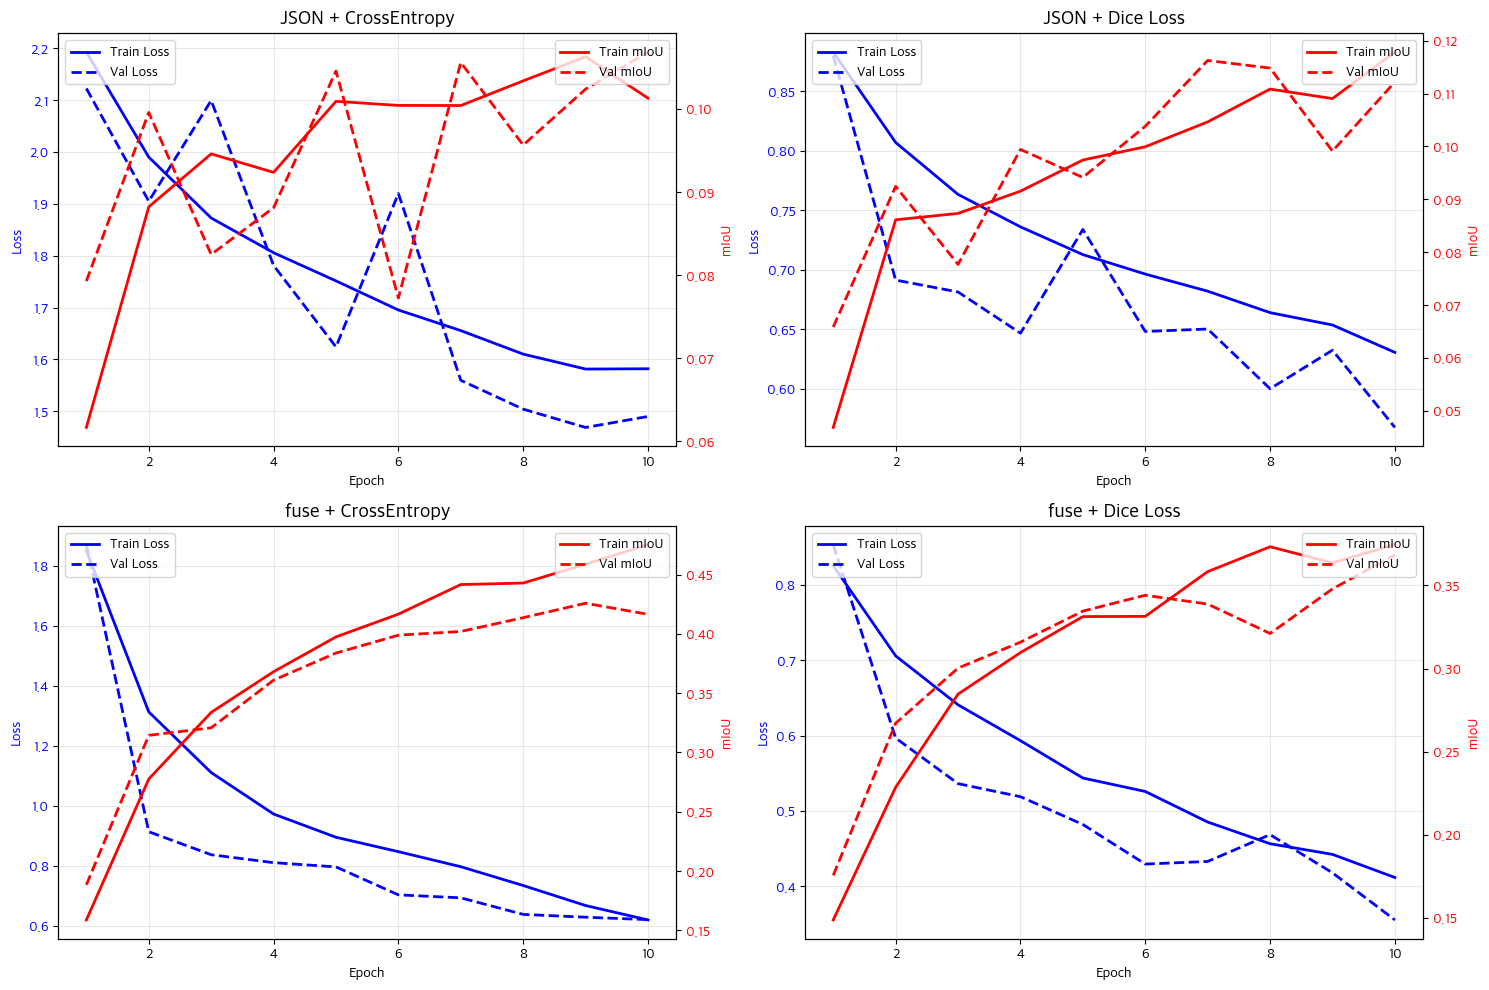

In [22]:
# 학습 곡선 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

experiments = ["JSON_CE", "JSON_Dice", "fuse_CE", "fuse_Dice"]
titles = ["JSON + CrossEntropy", "JSON + Dice Loss", "fuse + CrossEntropy", "fuse + Dice Loss"]

for idx, (exp_name, title) in enumerate(zip(experiments, titles)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    history = results[exp_name]["history"]
    epochs_range = range(1, len(history["train_loss"]) + 1)
    
    # Loss
    ax_loss = ax
    ax_loss.plot(epochs_range, history["train_loss"], "b-", label="Train Loss", linewidth=2)
    ax_loss.plot(epochs_range, history["val_loss"], "b--", label="Val Loss", linewidth=2)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss", color="b")
    ax_loss.tick_params(axis="y", labelcolor="b")
    ax_loss.legend(loc="upper left")
    ax_loss.grid(True, alpha=0.3)
    
    # IoU
    ax_iou = ax.twinx()
    ax_iou.plot(epochs_range, history["train_iou"], "r-", label="Train mIoU", linewidth=2)
    ax_iou.plot(epochs_range, history["val_iou"], "r--", label="Val mIoU", linewidth=2)
    ax_iou.set_ylabel("mIoU", color="r")
    ax_iou.tick_params(axis="y", labelcolor="r")
    ax_iou.legend(loc="upper right")
    
    ax.set_title(title, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

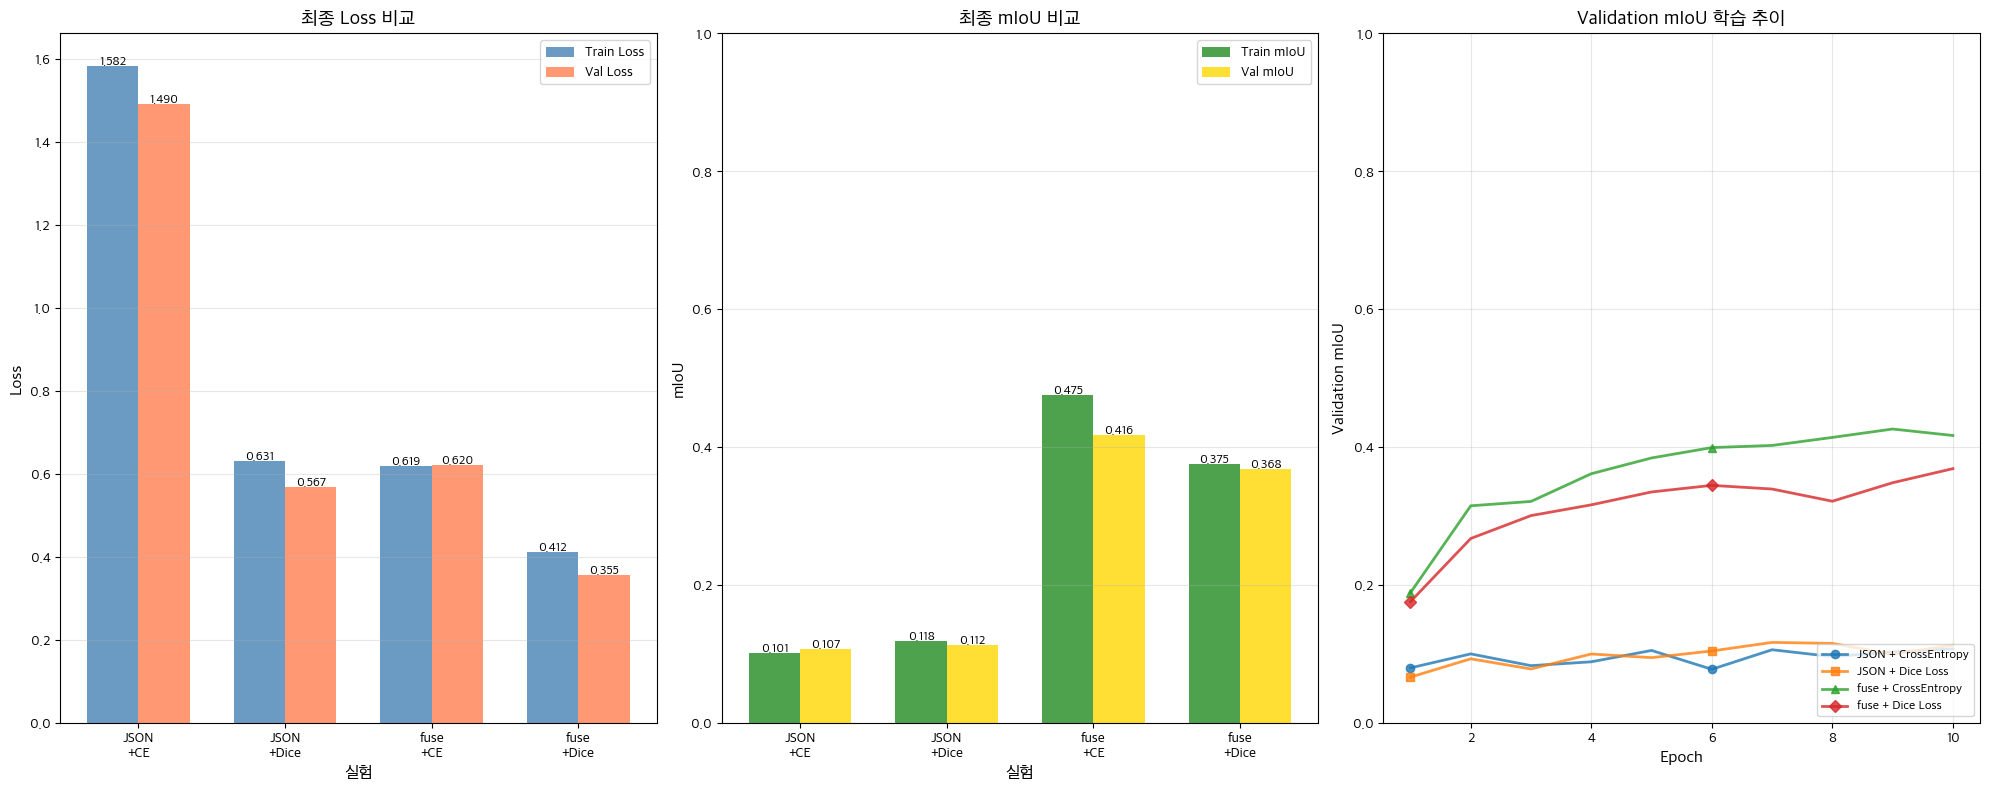

최종 비교 시각화 저장 완료: final_comparison.png


In [23]:
# 네 실험 최종 결과 통합 비교 시각화
fig = plt.figure(figsize=(20, 8))

# 1. Loss 비교 (왼쪽)
ax1 = plt.subplot(1, 3, 1)
x_pos = np.arange(len(experiments))
train_losses = [results[exp]["history"]["train_loss"][-1] for exp in experiments]
val_losses = [results[exp]["history"]["val_loss"][-1] for exp in experiments]

width = 0.35
bars1 = ax1.bar(x_pos - width/2, train_losses, width, label="Train Loss", color="steelblue", alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, val_losses, width, label="Val Loss", color="coral", alpha=0.8)

ax1.set_xlabel("실험", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("최종 Loss 비교", fontsize=14, fontweight="bold")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(["JSON\n+CE", "JSON\n+Dice", "fuse\n+CE", "fuse\n+Dice"], fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# 값 표시
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.3f}", ha="center", va="bottom", fontsize=9)

# 2. mIoU 비교 (중앙)
ax2 = plt.subplot(1, 3, 2)
train_ious = [results[exp]["history"]["train_iou"][-1] for exp in experiments]
val_ious = [results[exp]["history"]["val_iou"][-1] for exp in experiments]

bars3 = ax2.bar(x_pos - width/2, train_ious, width, label="Train mIoU", color="forestgreen", alpha=0.8)
bars4 = ax2.bar(x_pos + width/2, val_ious, width, label="Val mIoU", color="gold", alpha=0.8)

ax2.set_xlabel("실험", fontsize=12)
ax2.set_ylabel("mIoU", fontsize=12)
ax2.set_title("최종 mIoU 비교", fontsize=14, fontweight="bold")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(["JSON\n+CE", "JSON\n+Dice", "fuse\n+CE", "fuse\n+Dice"], fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim([0, 1.0])

# 값 표시
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars4:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.3f}", ha="center", va="bottom", fontsize=9)

# 3. Val mIoU 추이 비교 (오른쪽)
ax3 = plt.subplot(1, 3, 3)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
markers = ["o", "s", "^", "D"]

for idx, (exp_name, title, color, marker) in enumerate(zip(experiments, titles, colors, markers)):
    history = results[exp_name]["history"]
    epochs_range = range(1, len(history["val_iou"]) + 1)
    ax3.plot(epochs_range, history["val_iou"], 
            color=color, marker=marker, markevery=5, 
            label=title, linewidth=2, markersize=6, alpha=0.8)

ax3.set_xlabel("Epoch", fontsize=12)
ax3.set_ylabel("Validation mIoU", fontsize=12)
ax3.set_title("Validation mIoU 학습 추이", fontsize=14, fontweight="bold")
ax3.legend(loc="lower right", fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.0])

plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("최종 비교 시각화 저장 완료: final_comparison.png")


In [24]:
# 최종 성능 비교
comparison_df = pd.DataFrame(columns=["실험", "최종 Train Loss", "최종 Val Loss", "최종 Train mIoU", "최종 Val mIoU", "최고 Val mIoU"])

for exp_name, title in zip(experiments, titles):
    history = results[exp_name]["history"]
    
    comparison_df.loc[len(comparison_df)] = [
        title,
        f"{history['train_loss'][-1]:.4f}",
        f"{history['val_loss'][-1]:.4f}",
        f"{history['train_iou'][-1]:.4f}",
        f"{history['val_iou'][-1]:.4f}",
        f"{max(history['val_iou']):.4f}"
    ]

print("\n[최종 성능 비교]")
print(comparison_df.to_string(index=False))



[최종 성능 비교]
                 실험 최종 Train Loss 최종 Val Loss 최종 Train mIoU 최종 Val mIoU 최고 Val mIoU
JSON + CrossEntropy        1.5820      1.4900        0.1013      0.1068      0.1068
   JSON + Dice Loss        0.6306      0.5675        0.1178      0.1122      0.1163
fuse + CrossEntropy        0.6189      0.6199        0.4753      0.4165      0.4259
   fuse + Dice Loss        0.4117      0.3554        0.3746      0.3683      0.3683


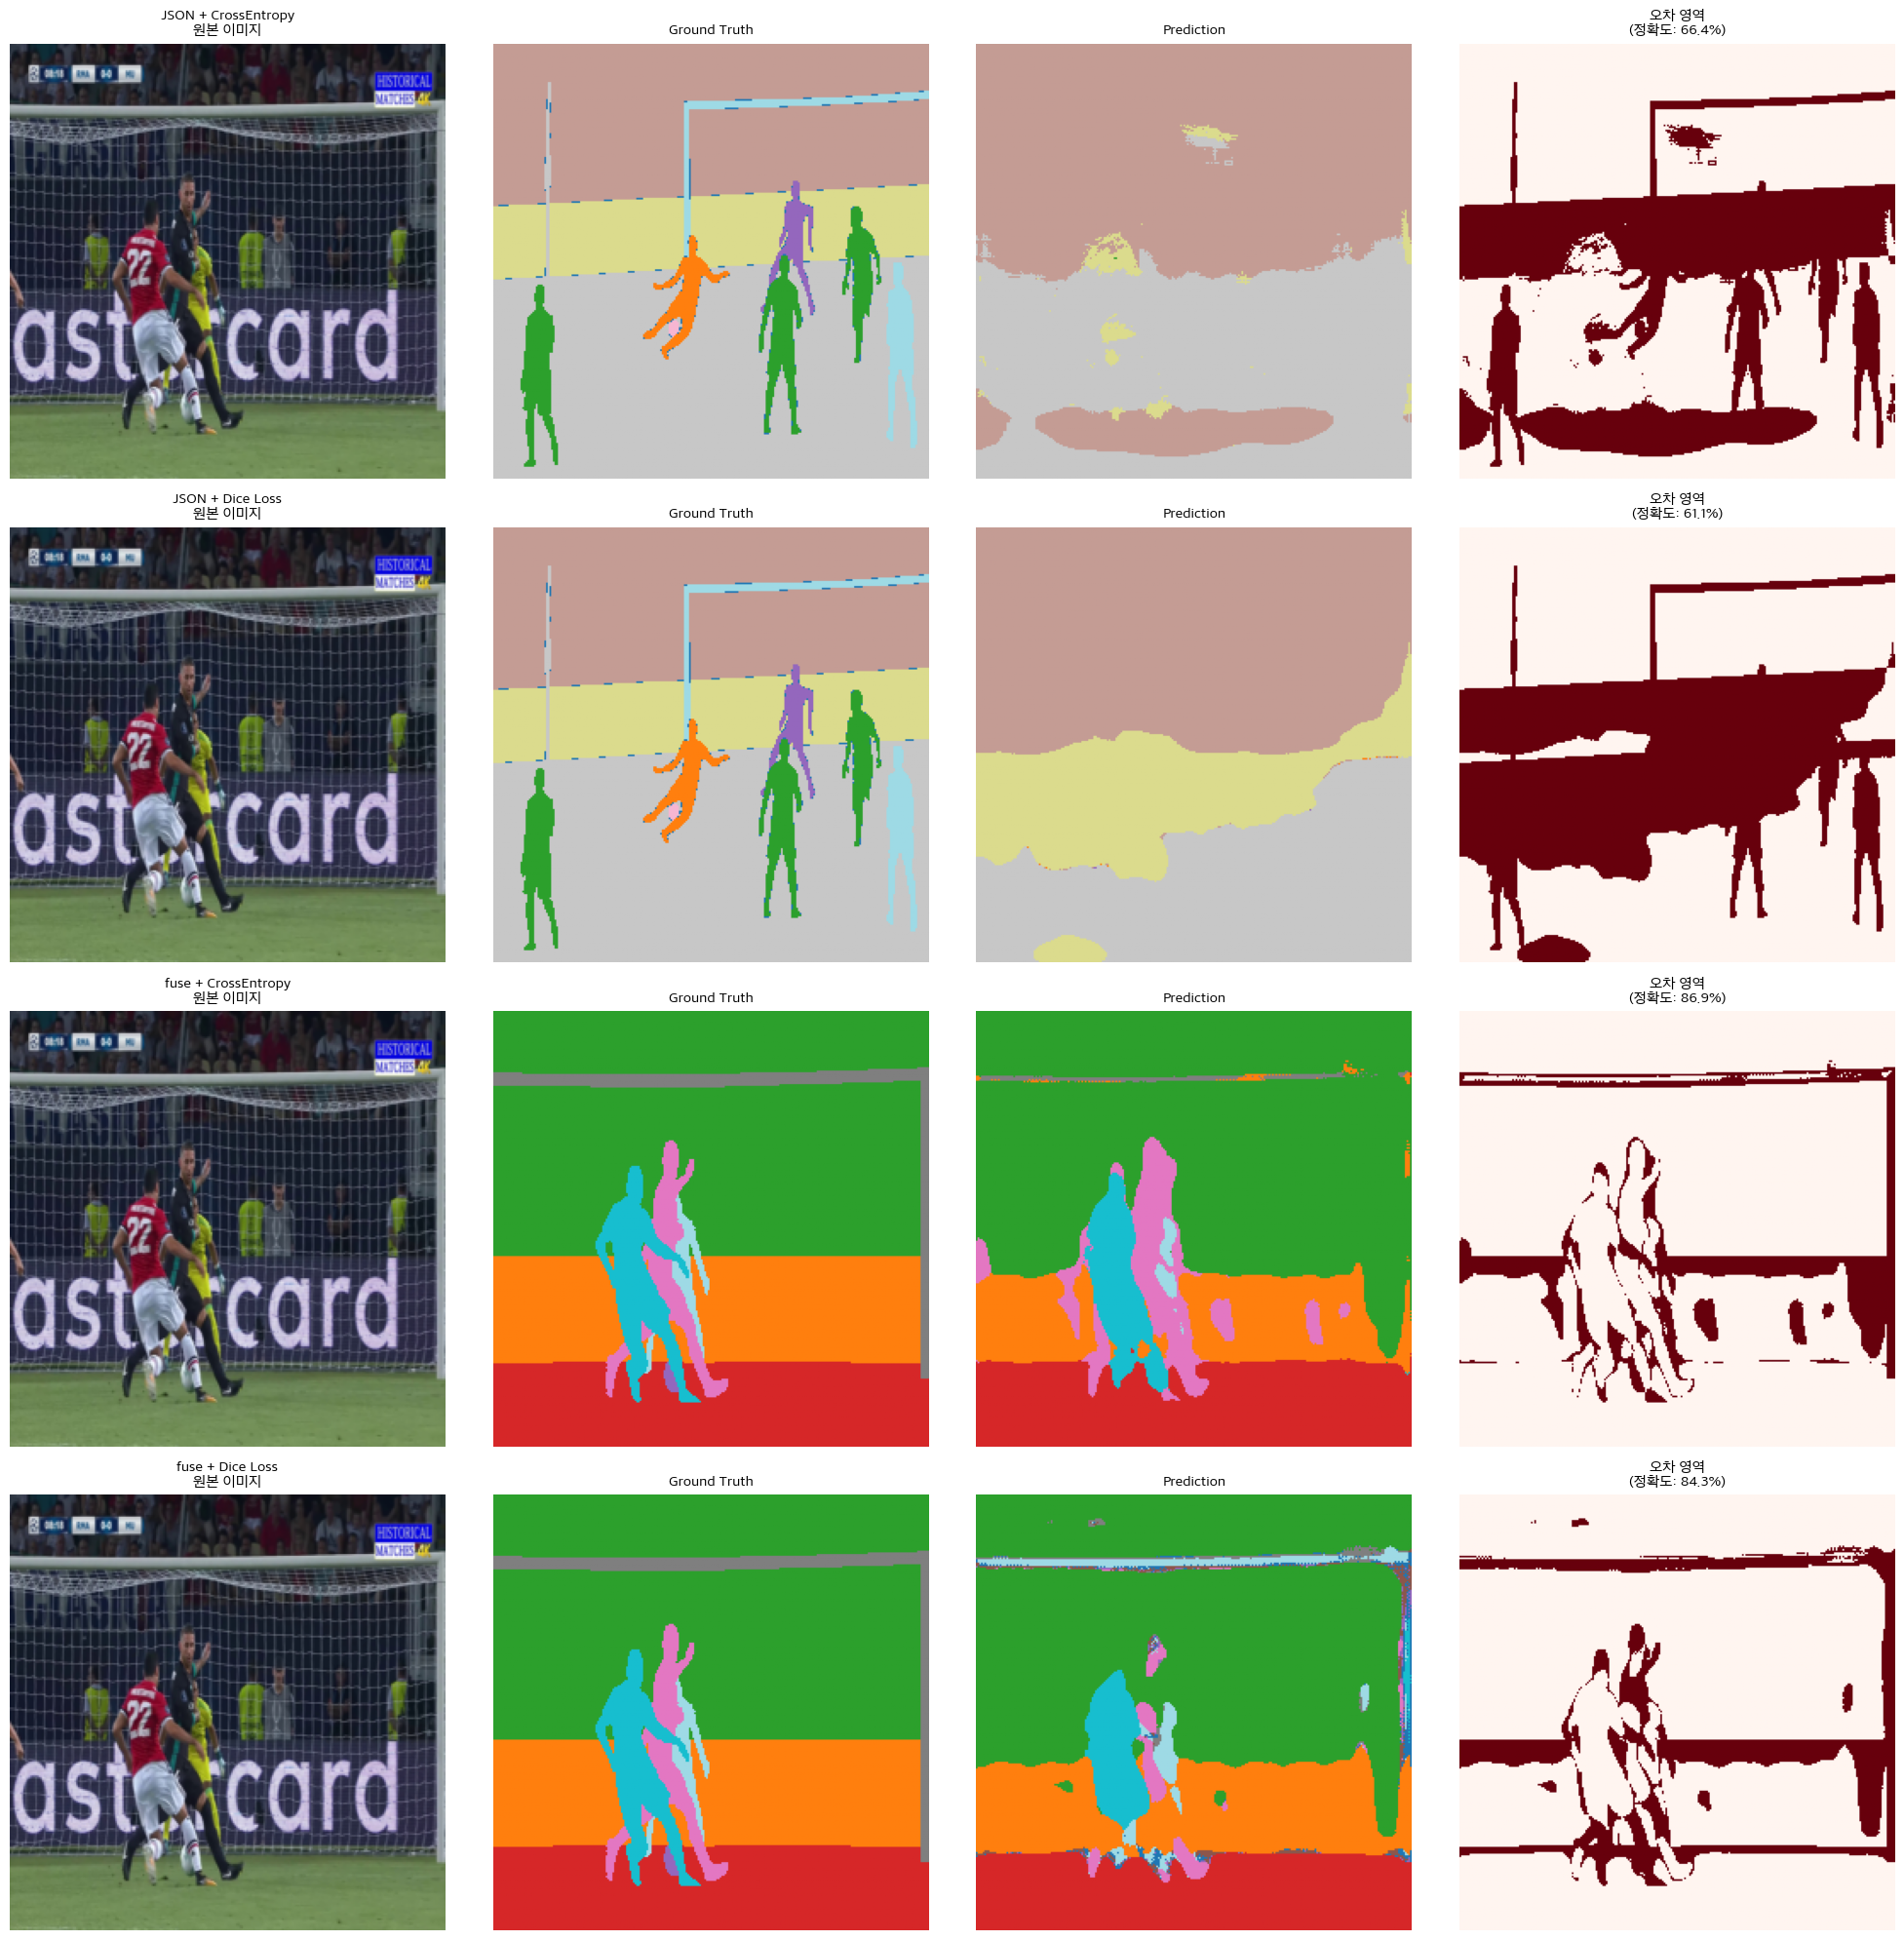


예측 결과 저장 완료: prediction_comparison.png
샘플 이미지 인덱스: 84


In [25]:
# 검증 세트에서 샘플 선택하여 시각화
sample_val_idx = random.choice(val_indices)

fig, axes = plt.subplots(4, 4, figsize=(20, 20))

# 원본 이미지
original_img = Image.open(NORM_PATH_LIST[sample_val_idx]).convert("RGB")
original_img_resized = original_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)

# JSON GT
json_dataset = FootballDataset([sample_val_idx], data_type="json")
_, json_gt = json_dataset[0]

# fuse GT
fuse_dataset = FootballDataset([sample_val_idx], data_type="fuse")
_, fuse_gt = fuse_dataset[0]

# 각 실험의 예측 결과
for idx, (exp_name, title) in enumerate(zip(experiments, titles)):
    row = idx
    model = results[exp_name]["model"]
    model.eval()
    
    # 데이터 타입에 따라 dataset 선택
    if "JSON" in exp_name:
        dataset = json_dataset
        gt_mask = json_gt
    else:
        dataset = fuse_dataset
        gt_mask = fuse_gt
    
    # 예측
    img_tensor, _ = dataset[0]
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze().numpy()
    
    # 시각화 (4열: 원본, GT, Prediction, 차이)
    axes[row, 0].imshow(original_img_resized)
    axes[row, 0].set_title(f"{title}\n원본 이미지", fontsize=11, fontweight="bold")
    axes[row, 0].axis("off")
    
    axes[row, 1].imshow(gt_mask, cmap="tab20", vmin=0, vmax=model.outc.out_channels-1)
    axes[row, 1].set_title("Ground Truth", fontsize=11)
    axes[row, 1].axis("off")
    
    axes[row, 2].imshow(pred_mask, cmap="tab20", vmin=0, vmax=model.outc.out_channels-1)
    axes[row, 2].set_title("Prediction", fontsize=11)
    axes[row, 2].axis("off")
    
    # 차이 시각화 (정답과 다른 픽셀)
    diff_mask = (gt_mask.numpy() != pred_mask).astype(np.uint8)
    axes[row, 3].imshow(diff_mask, cmap="Reds", vmin=0, vmax=1)
    axes[row, 3].set_title(f"오차 영역\n(정확도: {(1-diff_mask.mean())*100:.1f}%)", fontsize=11)
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

print(f"\n예측 결과 저장 완료: prediction_comparison.png")
print(f"샘플 이미지 인덱스: {sample_val_idx + 1}")
